# Import Necessary Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2

# Load and Transform Data

In [ ]:
data_dir = "/content/drive/MyDrive/Dataset_split"

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(data_dir, "train"),
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(data_dir, "val"),
    image_size=img_size,
    batch_size=batch_size
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(data_dir, "test"),
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 4914 files belonging to 4 classes.
Found 1054 files belonging to 4 classes.
Found 1055 files belonging to 4 classes.


# Placing Data into a Dataframe

In [ ]:
image_paths = []
labels = []

for root, dirs, files in os.walk(data_dir + "/train"):
    for file in files:
        image_paths.append(os.path.join(root, file))
        labels.append(os.path.basename(root))

df = pd.DataFrame({
    "image": image_paths,
    "label": labels
})

df.head()

,image,label
0,/content/drive/MyDrive/Dataset_split/train/pit...,pituitary
1,/content/drive/MyDrive/Dataset_split/train/pit...,pituitary
2,/content/drive/MyDrive/Dataset_split/train/pit...,pituitary
3,/content/drive/MyDrive/Dataset_split/train/pit...,pituitary
4,/content/drive/MyDrive/Dataset_split/train/pit...,pituitary


# Visualizing images from the dataset

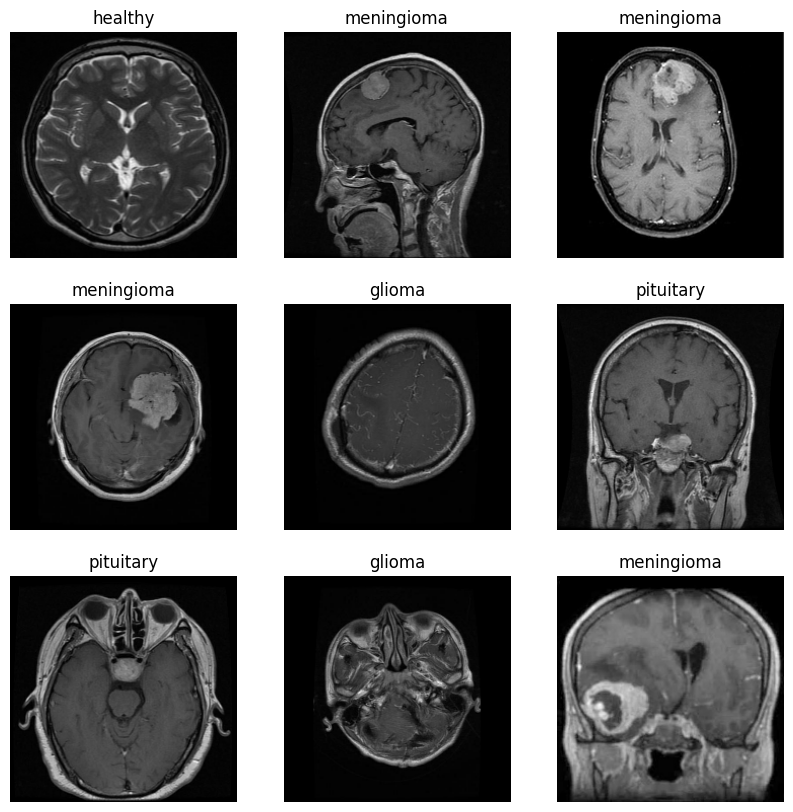

In [ ]:
plt.figure(figsize=(10,10))

# pastikan class_names ada
if 'class_names' not in globals():
    class_names = train_ds.class_names

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])  # convert ke int
        plt.axis("off")

# Data Preprocessing

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(data_augmentation(x)), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# Training the model

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # transfer learning

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 895s 3s/step - accuracy: 0.2987 - loss: 1.6165 - val_accuracy: 0.2846 - val_loss: 1.3763
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 350s 2s/step - accuracy: 0.3317 - loss: 1.4425 - val_accuracy: 0.2846 - val_loss: 1.3753
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.3504 - loss: 1.3695 - val_accuracy: 0.2846 - val_loss: 1.3592
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 311s 2s/step - accuracy: 0.3527 - loss: 1.3275 - val_accuracy: 0.2970 - val_loss: 1.3298
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.3738 - loss: 1.3158 - val_accuracy: 0.5275 - val_loss: 1.2990
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.3665 - loss: 1.2973 - val_accuracy: 0.4288 - val_loss: 1.2816
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.3820 - loss: 1.2859 - val_accuracy: 0.4877 - val_loss: 1.2528
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 328s 2

# Model Evaluation

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_acc)

33/33 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.4957 - loss: 1.4975
Test Loss     : 1.4974889755249023
Test Accuracy : 0.4957346022129059


# Computing Error Rate Analysis

Sedang memproses label asli...
Sedang melakukan prediksi pada data test...
67/67 ━━━━━━━━━━━━━━━━━━━━ 43s 637ms/step

 ERROR RATE ANALYSIS (FINAL)
Test Accuracy : 0.3794
Error Rate    : 0.6206 (62.06%)
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

      glioma       0.28      1.00      0.44       246
     healthy       0.88      0.52      0.65       304
  meningioma       0.30      0.01      0.02       256
   pituitary       0.00      0.00      0.00       264

    accuracy                           0.38      1070
   macro avg       0.37      0.38      0.28      1070
weighted avg       0.39      0.38      0.29      1070



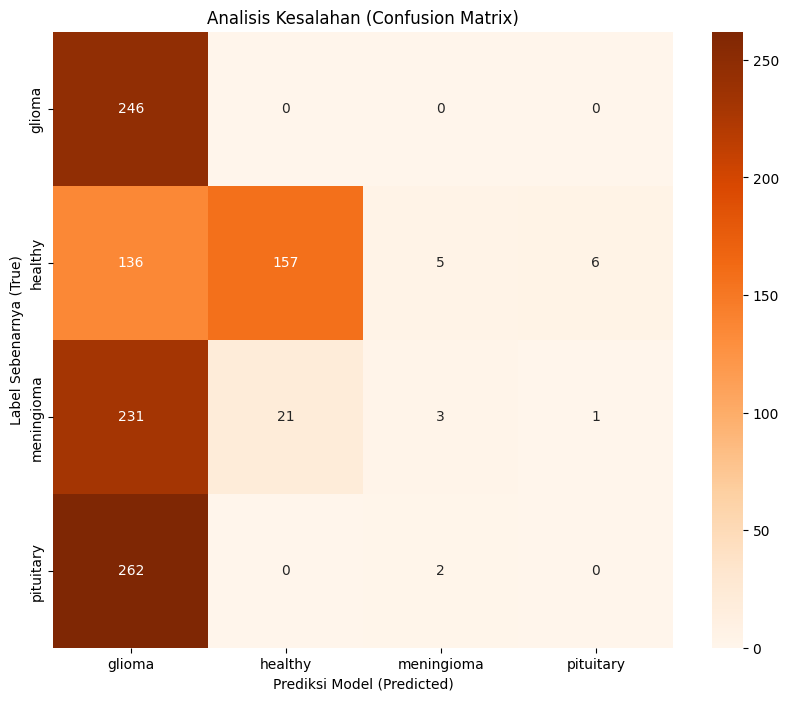

In [30]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# 1. Kumpulkan semua label asli dari test_ds
print("Sedang memproses label asli...")
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# 2. Lakukan prediksi pada seluruh test_ds
print("Sedang melakukan prediksi pada data test...")
Y_pred = model.predict(test_ds)
y_pred = np.argmax(Y_pred, axis=1) # Ambil indeks dengan probabilitas tertinggi

# 3. Hitung Accuracy dan Error Rate
accuracy = np.mean(y_pred == y_true)
error_rate = 1 - accuracy

print("\n" + "="*35)
print(f" ERROR RATE ANALYSIS (FINAL)")
print("="*35)
print(f"Test Accuracy : {accuracy:.4f}")
print(f"Error Rate    : {error_rate:.4f} ({error_rate*100:.2f}%)")
print("-" * 35)

# 4. Tampilkan Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 5. Visualisasi Confusion Matrix untuk melihat pola kesalahan
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Analisis Kesalahan (Confusion Matrix)')
plt.ylabel('Label Sebenarnya (True)')
plt.xlabel('Prediksi Model (Predicted)')
plt.show()


# Visualizing loss curves


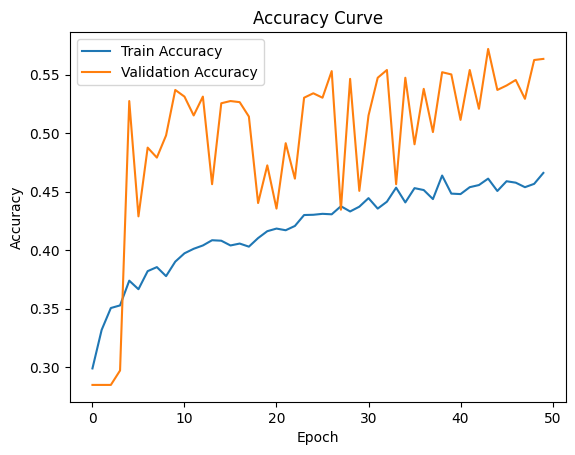

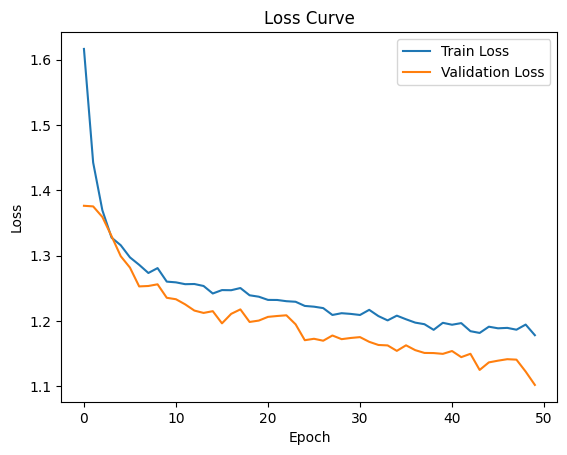

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Making predictions on the Test Data

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step


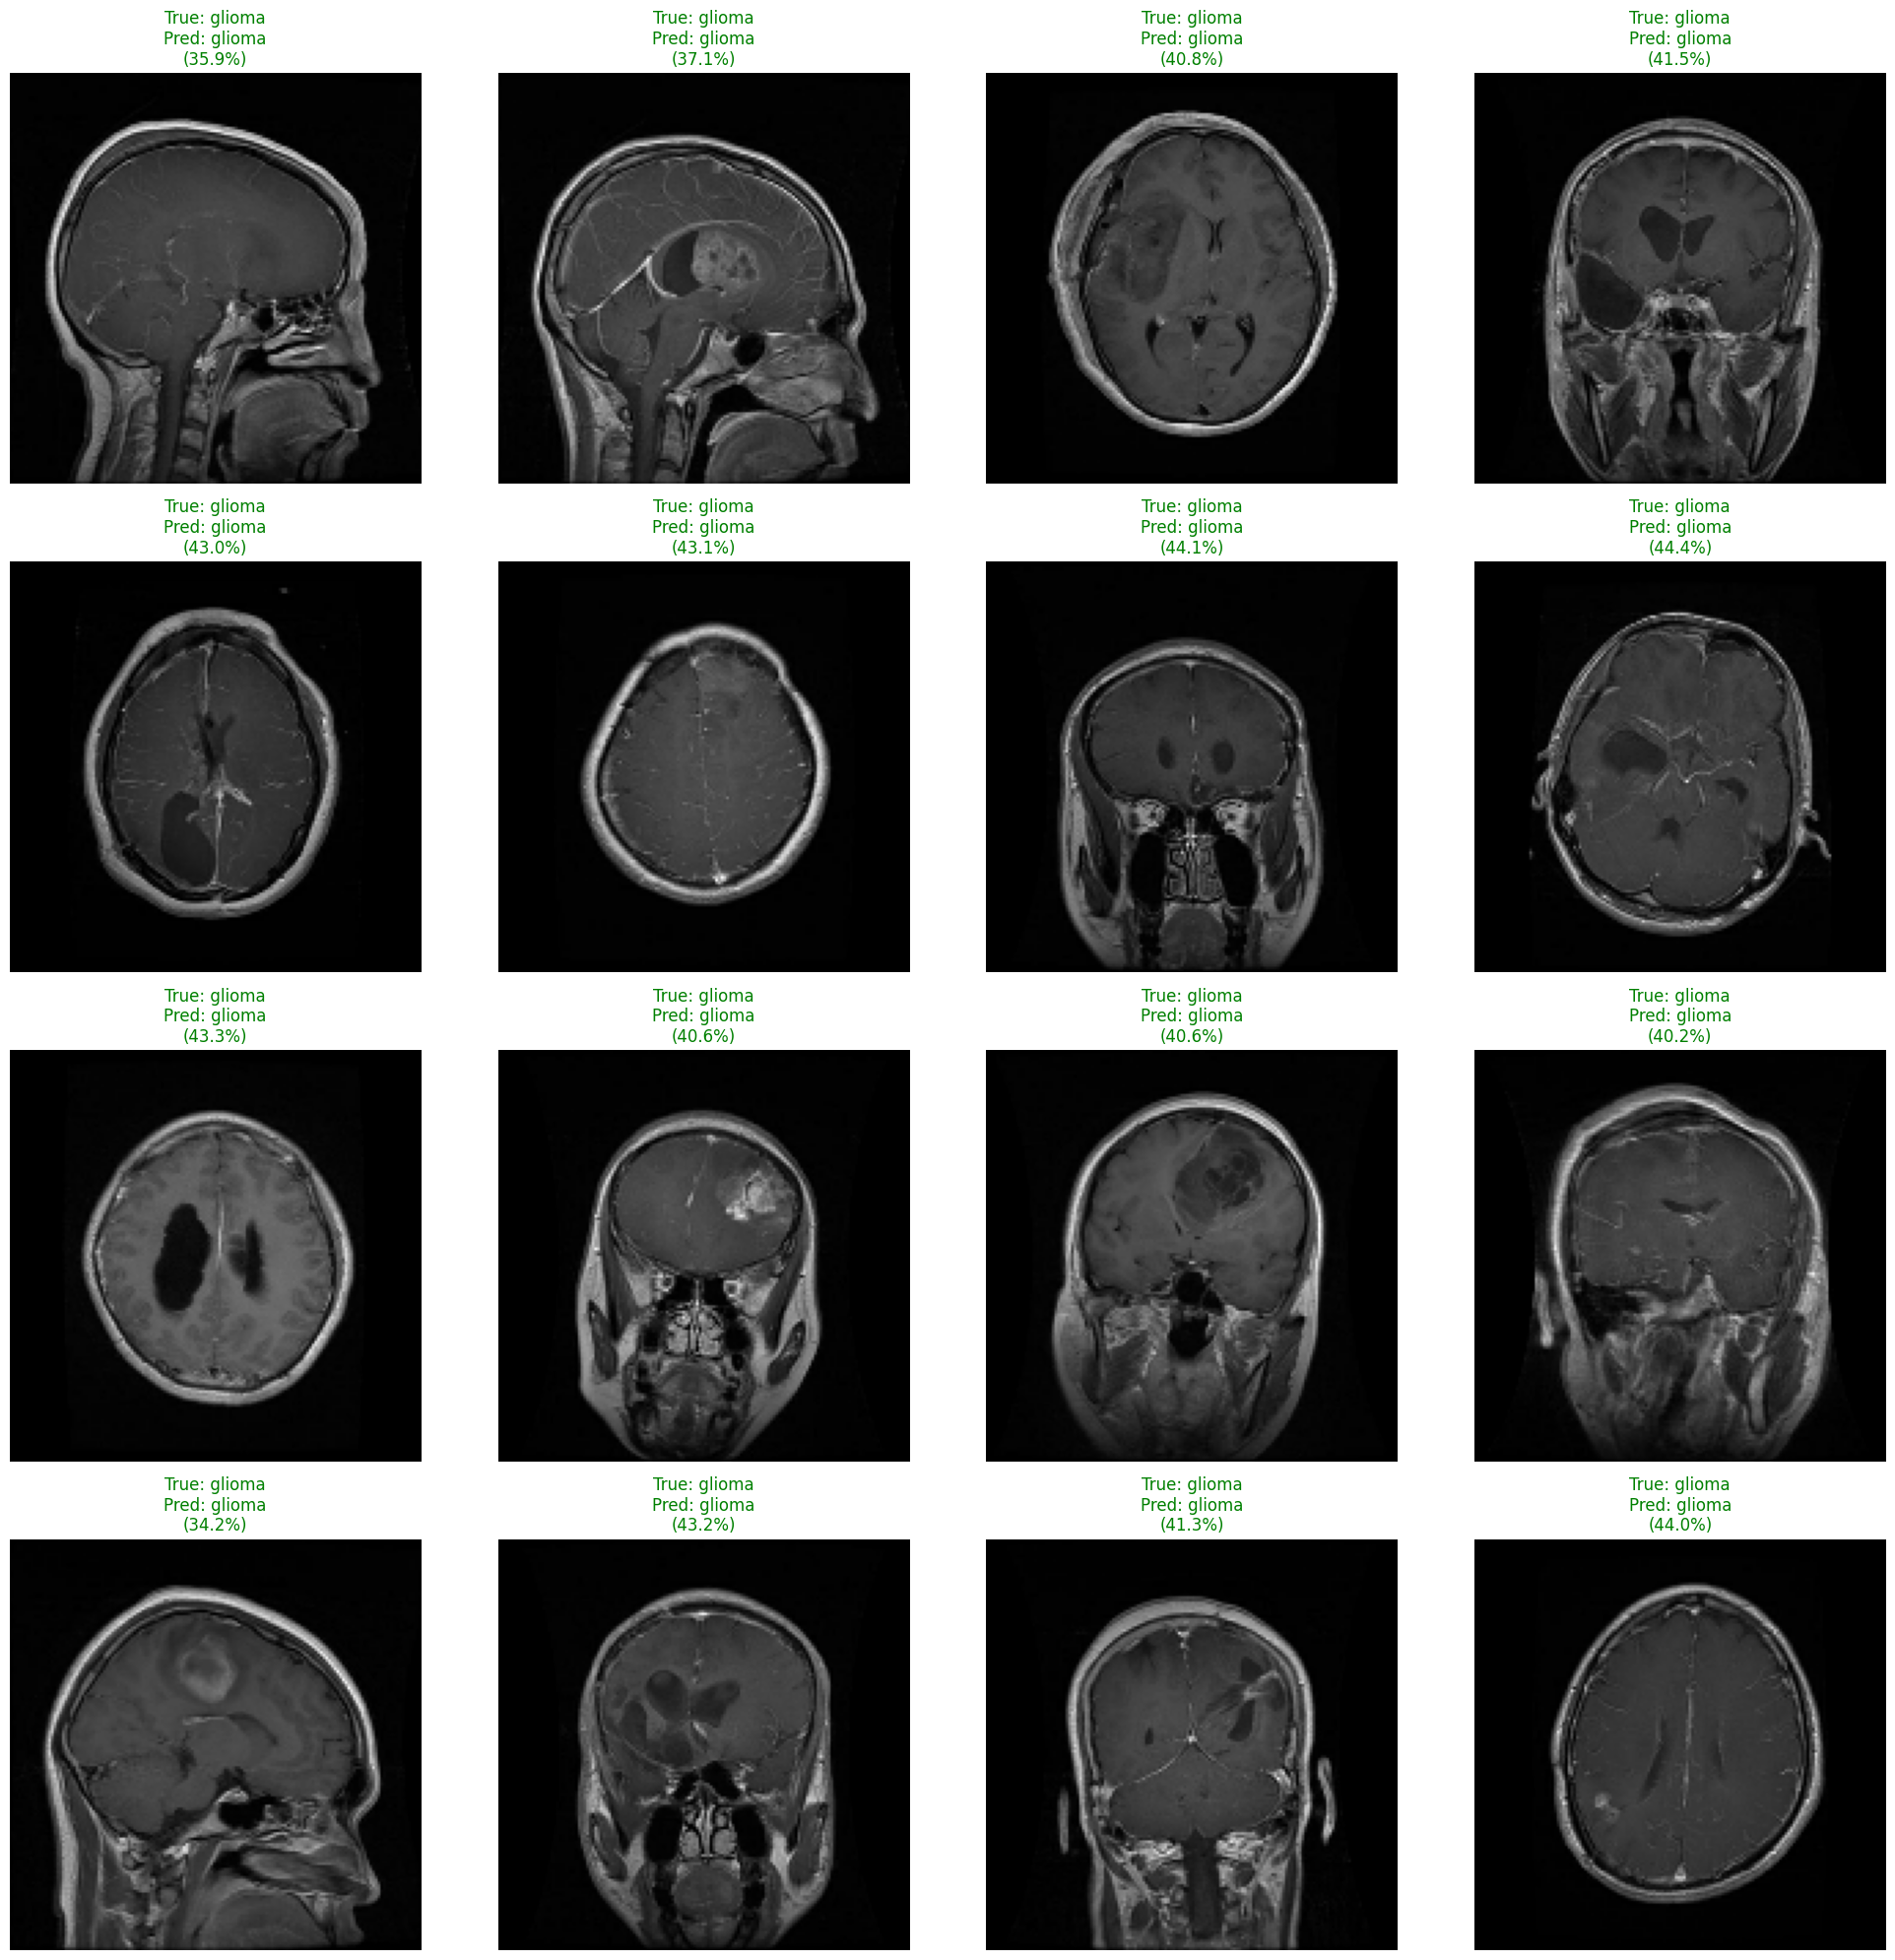

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Ambil satu batch dari test_ds (32 gambar)
for images, labels in test_ds.take(1):
    # 2. Lakukan prediksi
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    # 3. Visualisasi 16 gambar pertama dari batch tersebut
    plt.figure(figsize=(20, 20))
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)

        # Kembalikan ke format uint8 untuk plotting (jika sebelumnya di-rescale)
        # Jika tidak pakai rescaling manual, langsung images[i].numpy().astype("uint8")
        display_img = images[i].numpy()
        if np.max(display_img) <= 1.0:
            display_img = (display_img * 255).astype("uint8")
        else:
            display_img = display_img.astype("uint8")

        plt.imshow(display_img)

        actual = class_names[int(labels[i])]
        predicted = class_names[pred_labels[i]]
        confidence = np.max(preds[i]) * 100

        # Warna Hijau jika benar, Merah jika salah
        title_color = "green" if actual == predicted else "red"

        plt.title(f"True: {actual}\nPred: {predicted}\n({confidence:.1f}%)",
                  color=title_color, fontsize=12)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    break # Cukup tampilkan satu batch saja


# Grad-Cam Visualization

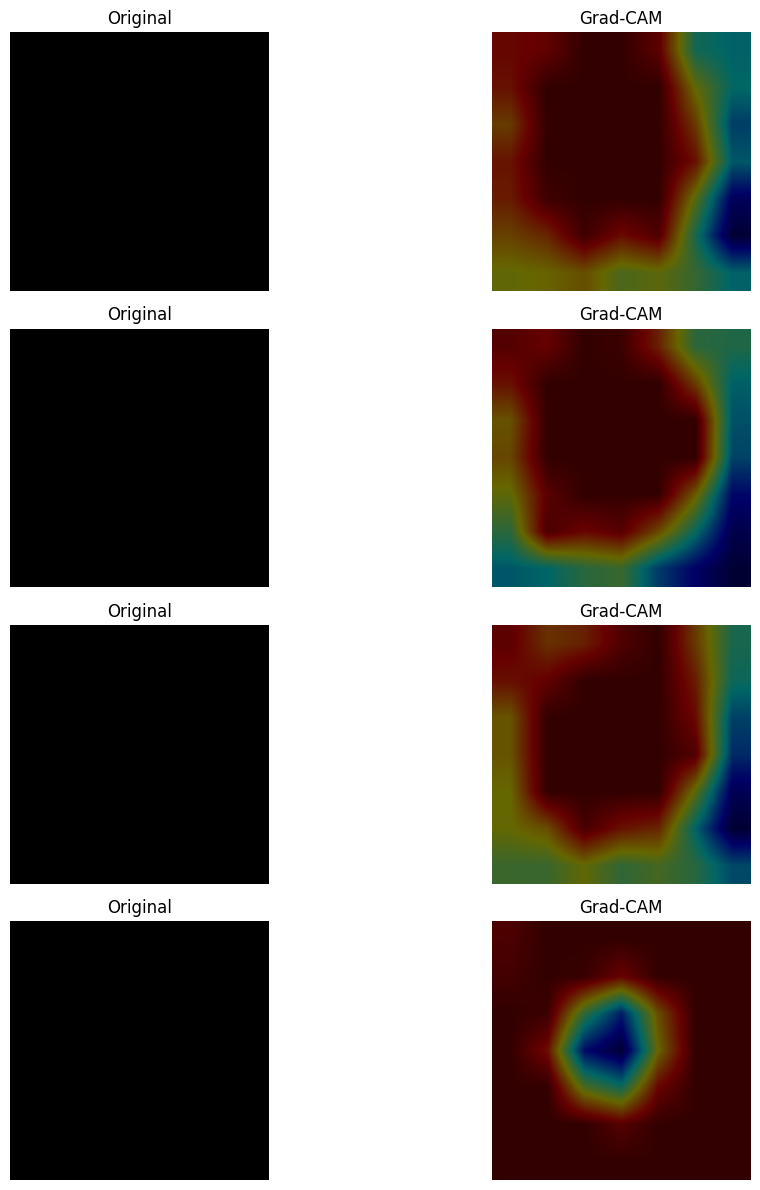

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

for images, labels in test_ds.take(1):

    for i in range(min(4, len(images))):

        img = images[i].numpy().astype("uint8")
        img_array = tf.expand_dims(images[i], axis=0)

        heatmap = make_gradcam_heatmap(
            img_array,
            model,
            "top_conv"   # layer terakhir EfficientNet
        )

        overlay = overlay_heatmap(img, heatmap)

        plt.subplot(4,2,2*i+1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(4,2,2*i+2)
        plt.imshow(overlay)
        plt.title("Grad-CAM")
        plt.axis("off")

plt.tight_layout()
plt.show()